# 05 Velocity Comparison

## 1. Purpose and Scope

This notebook compares RADAR and LiDAR vehicle-motion information in TruckScenes under the same annotation-derived reference-speed conditions.

The annotation-derived reference velocity developed in `02_Annotation_Reference_Velocity.ipynb` is used as the common motion reference. The 2D ground-plane speed remains the primary vehicle-speed metric, while the 3D reference speed is retained only where appropriate as a diagnostic measure.

The validated sensor-side results from the previous notebooks are reused without redefining the RADAR or LiDAR velocity-estimation methods. RADAR velocity is represented by the final stable RADAR-derived 2D target-velocity estimate developed in `03_RADAR.ipynb`. LiDAR velocity is represented by the LiDAR-derived target velocity developed in `04_LiDAR.ipynb`.

The comparison focuses on two separate questions:

* **Velocity performance:** how often each velocity-estimation method produces a usable estimate and how closely the available estimates agree with the common reference velocity.
* **Sensor information efficiency:** the availability, amount, and type of target-related information acquired under equivalent observation conditions.

Accuracy and availability are evaluated separately. A sensor or estimation method is not considered more accurate simply because it provides estimates for more intervals.

Target-associated RADAR returns and LiDAR points are also treated as different information units. Their counts are therefore analysed within each sensor modality rather than converted into a direct RADAR-to-LiDAR efficiency ratio.

The primary comparison is performed at the common keyframe/reference-interval level. Native sensor acquisition frequency is considered separately because RADAR and LiDAR operate at different observation frequencies and the previous target-level analyses do not use all intermediate sensor observations.


## 2. Build Common Comparison Dataset

A common interval-level comparison table is constructed using the valid annotation-derived vehicle-motion intervals as the base dataset.

Each row represents one target vehicle over one consecutive annotation interval. RADAR and LiDAR information is added using left joins so that intervals without a valid sensor-derived velocity estimate are retained.

This structure allows velocity availability and velocity accuracy to be analysed separately.

In [10]:
from pathlib import Path

import pandas as pd


RESULTS_ROOT = Path("../results/validated")


vehicle_reference_df = pd.read_pickle(
    RESULTS_ROOT / "vehicle_reference_df.pkl"
)

target_radar_df = pd.read_pickle(
    RESULTS_ROOT / "target_radar_df.pkl"
)

radar_velocity_df = pd.read_pickle(
    RESULTS_ROOT / "radar_velocity_df.pkl"
)

target_lidar_df = pd.read_pickle(
    RESULTS_ROOT / "target_lidar_df.pkl"
)

lidar_velocity_df = pd.read_pickle(
    RESULTS_ROOT / "lidar_velocity_df.pkl"
)


print("Reference intervals:", len(vehicle_reference_df))
print("RADAR target rows:", len(target_radar_df))
print("Stable RADAR velocity intervals:", len(radar_velocity_df))
print("LiDAR target rows:", len(target_lidar_df))
print("LiDAR velocity intervals:", len(lidar_velocity_df))

Reference intervals: 15743
RADAR target rows: 9588
Stable RADAR velocity intervals: 3016
LiDAR target rows: 16501
LiDAR velocity intervals: 8007


In [11]:
# Check the intended join keys before building the comparison table.

tables_and_keys = {
    "Reference": (
        vehicle_reference_df,
        ["start_annotation_token", "end_annotation_token"],
    ),
    "RADAR velocity": (
        radar_velocity_df,
        ["start_annotation_token", "end_annotation_token"],
    ),
    "LiDAR velocity": (
        lidar_velocity_df,
        ["start_annotation_token", "end_annotation_token"],
    ),
    "RADAR target information": (
        target_radar_df,
        ["annotation_token"],
    ),
    "LiDAR target information": (
        target_lidar_df,
        ["annotation_token"],
    ),
}

for name, (df, keys) in tables_and_keys.items():
    duplicate_count = df.duplicated(subset=keys).sum()

    print(name)
    print("  Rows:", len(df))
    print("  Duplicate keys:", duplicate_count)
    print()

Reference
  Rows: 15743
  Duplicate keys: 0

RADAR velocity
  Rows: 3016
  Duplicate keys: 0

LiDAR velocity
  Rows: 8007
  Duplicate keys: 0

RADAR target information
  Rows: 9588
  Duplicate keys: 0

LiDAR target information
  Rows: 16501
  Duplicate keys: 0



In [12]:
# Build the common interval-level velocity comparison table.

reference_columns = [
    "start_annotation_token",
    "end_annotation_token",
    "instance_token",
    "category",
    "vx_mps",
    "vy_mps",
    "vz_mps",
    "speed_2d_mps",
    "speed_3d_mps",
]

radar_columns = [
    "start_annotation_token",
    "end_annotation_token",
    "radar_vx_mps",
    "radar_vy_mps",
    "radar_speed_2d_mps",
]

lidar_columns = [
    "start_annotation_token",
    "end_annotation_token",
    "lidar_vx_mps",
    "lidar_vy_mps",
    "lidar_vz_mps",
    "lidar_speed_2d_mps",
    "lidar_speed_3d_mps",
]

comparison_df = (
    vehicle_reference_df[reference_columns]
    .merge(
        radar_velocity_df[radar_columns],
        on=[
            "start_annotation_token",
            "end_annotation_token",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        lidar_velocity_df[lidar_columns],
        on=[
            "start_annotation_token",
            "end_annotation_token",
        ],
        how="left",
        validate="one_to_one",
    )
)

comparison_df["radar_velocity_available"] = (
    comparison_df["radar_speed_2d_mps"].notna()
)

comparison_df["lidar_velocity_available"] = (
    comparison_df["lidar_speed_2d_mps"].notna()
)

print("Comparison rows:", len(comparison_df))
print(
    "RADAR velocity available:",
    comparison_df["radar_velocity_available"].sum(),
)
print(
    "LiDAR velocity available:",
    comparison_df["lidar_velocity_available"].sum(),
)

Comparison rows: 15743
RADAR velocity available: 3016
LiDAR velocity available: 8007


In [13]:
# Classify velocity-estimation availability for each reference interval.

comparison_df["availability_group"] = "Neither"

comparison_df.loc[
    comparison_df["radar_velocity_available"]
    & comparison_df["lidar_velocity_available"],
    "availability_group",
] = "Both"

comparison_df.loc[
    comparison_df["radar_velocity_available"]
    & ~comparison_df["lidar_velocity_available"],
    "availability_group",
] = "RADAR only"

comparison_df.loc[
    ~comparison_df["radar_velocity_available"]
    & comparison_df["lidar_velocity_available"],
    "availability_group",
] = "LiDAR only"


availability_order = [
    "Both",
    "RADAR only",
    "LiDAR only",
    "Neither",
]

availability_summary = (
    comparison_df["availability_group"]
    .value_counts()
    .reindex(availability_order, fill_value=0)
    .rename("Count")
    .to_frame()
)

availability_summary["Percentage"] = (
    availability_summary["Count"]
    / len(comparison_df)
    * 100
).round(2)

availability_summary

,Count,Percentage
availability_group,,
Both,2899,18.41
RADAR only,117,0.74
LiDAR only,5108,32.45
Neither,7619,48.40


In [14]:
# Add keyframe-level sensor information to each reference interval.

radar_info = target_radar_df[
    [
        "annotation_token",
        "radar_return_count",
        "radar_sensor_count",
    ]
].copy()

lidar_info = target_lidar_df[
    [
        "annotation_token",
        "lidar_point_count",
    ]
].copy()


# Start-keyframe RADAR information.
comparison_df = comparison_df.merge(
    radar_info.rename(columns={
        "annotation_token": "start_annotation_token",
        "radar_return_count": "radar_start_return_count",
        "radar_sensor_count": "radar_start_sensor_count",
    }),
    on="start_annotation_token",
    how="left",
    validate="many_to_one",
)

# End-keyframe RADAR information.
comparison_df = comparison_df.merge(
    radar_info.rename(columns={
        "annotation_token": "end_annotation_token",
        "radar_return_count": "radar_end_return_count",
        "radar_sensor_count": "radar_end_sensor_count",
    }),
    on="end_annotation_token",
    how="left",
    validate="many_to_one",
)

# Start-keyframe LiDAR information.
comparison_df = comparison_df.merge(
    lidar_info.rename(columns={
        "annotation_token": "start_annotation_token",
        "lidar_point_count": "lidar_start_point_count",
    }),
    on="start_annotation_token",
    how="left",
    validate="many_to_one",
)

# End-keyframe LiDAR information.
comparison_df = comparison_df.merge(
    lidar_info.rename(columns={
        "annotation_token": "end_annotation_token",
        "lidar_point_count": "lidar_end_point_count",
    }),
    on="end_annotation_token",
    how="left",
    validate="many_to_one",
)


# Missing RADAR rows mean no target-associated RADAR return.
radar_count_columns = [
    "radar_start_return_count",
    "radar_end_return_count",
    "radar_start_sensor_count",
    "radar_end_sensor_count",
]

comparison_df[radar_count_columns] = (
    comparison_df[radar_count_columns]
    .fillna(0)
)


# Information availability at both interval endpoints.
comparison_df["radar_info_available"] = (
    (comparison_df["radar_start_return_count"] > 0)
    & (comparison_df["radar_end_return_count"] > 0)
)

comparison_df["lidar_info_available"] = (
    (comparison_df["lidar_start_point_count"] > 0)
    & (comparison_df["lidar_end_point_count"] > 0)
)


# Total target-associated information across the two keyframes.
comparison_df["radar_return_count"] = (
    comparison_df["radar_start_return_count"]
    + comparison_df["radar_end_return_count"]
)

comparison_df["lidar_point_count"] = (
    comparison_df["lidar_start_point_count"]
    + comparison_df["lidar_end_point_count"]
)


print("Comparison rows:", len(comparison_df))

print(
    "RADAR information available at both endpoints:",
    comparison_df["radar_info_available"].sum(),
)

print(
    "LiDAR information available at both endpoints:",
    comparison_df["lidar_info_available"].sum(),
)

Comparison rows: 15743
RADAR information available at both endpoints: 7706
LiDAR information available at both endpoints: 15743


In [15]:
# Check the relationship between sensor-information availability
# and velocity-estimation availability.

radar_invalid = (
    comparison_df["radar_velocity_available"]
    & ~comparison_df["radar_info_available"]
).sum()

lidar_invalid = (
    comparison_df["lidar_velocity_available"]
    & ~comparison_df["lidar_info_available"]
).sum()


radar_info_no_velocity = (
    comparison_df["radar_info_available"]
    & ~comparison_df["radar_velocity_available"]
).sum()

lidar_info_no_velocity = (
    comparison_df["lidar_info_available"]
    & ~comparison_df["lidar_velocity_available"]
).sum()


print(
    "RADAR velocity available without information:",
    radar_invalid,
)

print(
    "LiDAR velocity available without information:",
    lidar_invalid,
)

print()

print(
    "RADAR information available but no stable velocity:",
    radar_info_no_velocity,
)

print(
    "LiDAR information available but no derived velocity:",
    lidar_info_no_velocity,
)

RADAR velocity available without information: 0
LiDAR velocity available without information: 0

RADAR information available but no stable velocity: 4690
LiDAR information available but no derived velocity: 7736


## 3. Compare Velocity Availability and Accuracy

Velocity-estimation availability and velocity accuracy are evaluated separately.

Availability is measured relative to all valid annotation-derived reference intervals. RADAR availability represents intervals with a stable validated 2D RADAR velocity estimate, while LiDAR availability represents intervals for which the current LiDAR velocity-estimation baseline produces a valid estimate.

Accuracy is evaluated only where the corresponding sensor-derived velocity is available. The primary error metric is the absolute difference between the sensor-derived 2D speed and the annotation-derived 2D reference speed.

Two accuracy views are considered:

- sensor-specific performance using all available estimates from each method;
- matched performance using only reference intervals where both RADAR and LiDAR velocity estimates are available.

The matched subset is used for the direct RADAR–LiDAR accuracy comparison because both methods are then evaluated under exactly the same reference intervals.

In [16]:
# Calculate 2D absolute speed errors.

comparison_df["radar_abs_error_2d_mps"] = (
    comparison_df["radar_speed_2d_mps"]
    - comparison_df["speed_2d_mps"]
).abs()

comparison_df["lidar_abs_error_2d_mps"] = (
    comparison_df["lidar_speed_2d_mps"]
    - comparison_df["speed_2d_mps"]
).abs()


# Sensor-specific accuracy summaries.
accuracy_summary = pd.DataFrame({
    "Available intervals": [
        comparison_df["radar_velocity_available"].sum(),
        comparison_df["lidar_velocity_available"].sum(),
    ],
    "Availability (%)": [
        comparison_df["radar_velocity_available"].mean() * 100,
        comparison_df["lidar_velocity_available"].mean() * 100,
    ],
    "Median absolute error (m/s)": [
        comparison_df["radar_abs_error_2d_mps"].median(),
        comparison_df["lidar_abs_error_2d_mps"].median(),
    ],
    "Mean absolute error (m/s)": [
        comparison_df["radar_abs_error_2d_mps"].mean(),
        comparison_df["lidar_abs_error_2d_mps"].mean(),
    ],
}, index=["RADAR", "LiDAR"])

accuracy_summary.round(3)

,Available intervals,Availability (%),Median absolute error (m/s),Mean absolute error (m/s)
RADAR,3016,19.158,0.277,7.429
LiDAR,8007,50.861,0.224,0.510


In [17]:
# Compare RADAR and LiDAR accuracy on the same matched intervals.

matched_df = comparison_df[
    comparison_df["radar_velocity_available"]
    & comparison_df["lidar_velocity_available"]
].copy()


matched_accuracy_summary = pd.DataFrame({
    "Matched intervals": [
        len(matched_df),
        len(matched_df),
    ],
    "Median absolute error (m/s)": [
        matched_df["radar_abs_error_2d_mps"].median(),
        matched_df["lidar_abs_error_2d_mps"].median(),
    ],
    "Mean absolute error (m/s)": [
        matched_df["radar_abs_error_2d_mps"].mean(),
        matched_df["lidar_abs_error_2d_mps"].mean(),
    ],
    "90th percentile error (m/s)": [
        matched_df["radar_abs_error_2d_mps"].quantile(0.90),
        matched_df["lidar_abs_error_2d_mps"].quantile(0.90),
    ],
}, index=["RADAR", "LiDAR"])

matched_accuracy_summary.round(3)

,Matched intervals,Median absolute error (m/s),Mean absolute error (m/s),90th percentile error (m/s)
RADAR,2899,0.266,6.455,9.558
LiDAR,2899,0.263,0.613,1.437


### 3.1 Velocity-Estimation Availability

Velocity-estimation availability is first compared across all valid reference intervals.

Availability represents the proportion of annotation-derived reference intervals for which the validated sensor-specific velocity-estimation method produces a usable estimate.

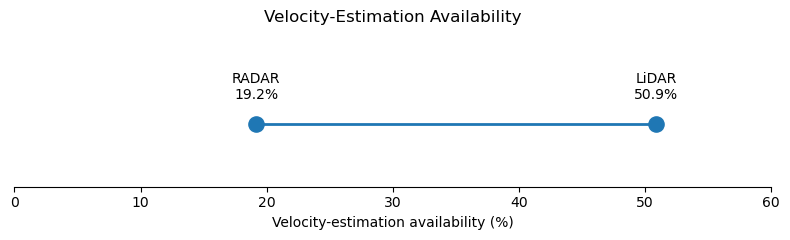

In [18]:
# Compare velocity-estimation availability using a dumbbell plot.

import matplotlib.pyplot as plt

radar_availability = (
    comparison_df["radar_velocity_available"].mean() * 100
)

lidar_availability = (
    comparison_df["lidar_velocity_available"].mean() * 100
)


fig, ax = plt.subplots(figsize=(8, 2.5))

# Connect the two availability values.
ax.plot(
    [radar_availability, lidar_availability],
    [0, 0],
    linewidth=2,
)

# Plot the two sensor values.
ax.scatter(
    [radar_availability, lidar_availability],
    [0, 0],
    s=120,
)

# Value labels.
ax.text(
    radar_availability,
    0.08,
    f"RADAR\n{radar_availability:.1f}%",
    ha="center",
)

ax.text(
    lidar_availability,
    0.08,
    f"LiDAR\n{lidar_availability:.1f}%",
    ha="center",
)

ax.set_xlabel(
    "Velocity-estimation availability (%)"
)

ax.set_title(
    "Velocity-Estimation Availability"
)

ax.set_xlim(0, 60)
ax.set_ylim(-0.2, 0.3)

ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Absolute Error Distribution on Matched Intervals

A direct accuracy comparison is performed using the 2,899 reference intervals for which both RADAR and LiDAR velocity estimates are available.

The empirical cumulative distribution of 2D absolute speed error is used to show both typical performance and the upper error tail without removing observations.

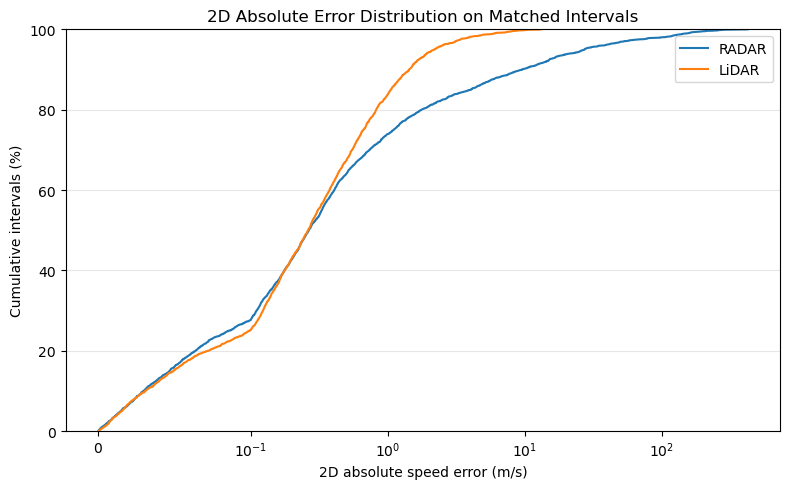

In [19]:
import numpy as np


# Build empirical cumulative distributions for the matched subset.

radar_errors = np.sort(
    matched_df["radar_abs_error_2d_mps"].dropna().to_numpy()
)

lidar_errors = np.sort(
    matched_df["lidar_abs_error_2d_mps"].dropna().to_numpy()
)

radar_ecdf = (
    np.arange(1, len(radar_errors) + 1)
    / len(radar_errors)
    * 100
)

lidar_ecdf = (
    np.arange(1, len(lidar_errors) + 1)
    / len(lidar_errors)
    * 100
)


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    radar_errors,
    radar_ecdf,
    label="RADAR",
)

ax.plot(
    lidar_errors,
    lidar_ecdf,
    label="LiDAR",
)

ax.set_xscale(
    "symlog",
    linthresh=0.1,
)

ax.set_xlabel(
    "2D absolute speed error (m/s)"
)

ax.set_ylabel(
    "Cumulative intervals (%)"
)

ax.set_title(
    "2D Absolute Error Distribution on Matched Intervals"
)

ax.set_ylim(0, 100)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

The matched error distributions show similar typical performance at low absolute errors, consistent with the nearly identical median errors of the two methods. However, the RADAR distribution has a substantially heavier upper tail. LiDAR reaches higher cumulative coverage at moderate error thresholds, while a smaller subset of RADAR estimates produces very large errors.

This difference is reflected in the matched mean and 90th-percentile errors and indicates that the current RADAR baseline is less consistent despite having a similar median error.

## 4. Compare Velocity Performance by Reference Speed

Velocity performance is next examined across the common annotation-derived reference-speed ranges.

The same speed ranges used in the previous analyses are retained so that changes in velocity-estimation availability and accuracy can be compared consistently across vehicle-motion conditions.

Both sensor-specific availability and matched accuracy are considered. The number of available observations in each speed range is checked before interpreting error statistics.

In [20]:
# Assign the common reference-speed ranges.

comparison_df["reference_speed_kmh"] = (
    comparison_df["speed_2d_mps"] * 3.6
)

speed_bins = [
    0,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    110,
    float("inf"),
]

speed_labels = [
    "0–<10",
    "10–<20",
    "20–<30",
    "30–<40",
    "40–<50",
    "50–<60",
    "60–<70",
    "70–<80",
    "80–<90",
    "90–<100",
    "100–<110",
    "≥110",
]

comparison_df["speed_range_kmh"] = pd.cut(
    comparison_df["reference_speed_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
)


speed_range_counts = (
    comparison_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .agg(
        Reference_intervals=(
            "start_annotation_token",
            "size",
        ),
        RADAR_available=(
            "radar_velocity_available",
            "sum",
        ),
        LiDAR_available=(
            "lidar_velocity_available",
            "sum",
        ),
    )
)

speed_range_counts["Both_available"] = (
    comparison_df[
        comparison_df["radar_velocity_available"]
        & comparison_df["lidar_velocity_available"]
    ]
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .size()
    .reindex(
        speed_range_counts.index,
        fill_value=0,
    )
)

speed_range_counts

,Reference_intervals,RADAR_available,LiDAR_available,Both_available
speed_range_kmh,,,,
0–<10,6870,1594,3960,1538
10–<20,2028,309,1167,298
20–<30,1211,200,573,196
30–<40,799,145,354,140
40–<50,510,37,142,34
50–<60,424,62,148,59
60–<70,542,92,243,89
70–<80,823,175,344,166
80–<90,797,183,409,176


In [21]:
# Rebuild the matched subset after adding the reference-speed ranges.

matched_df = comparison_df[
    comparison_df["radar_velocity_available"]
    & comparison_df["lidar_velocity_available"]
].copy()

In [22]:
# Summarise velocity availability and matched accuracy by reference-speed range.

speed_performance_summary = (
    comparison_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .agg(
        Reference_intervals=(
            "start_annotation_token",
            "size",
        ),
        RADAR_available=(
            "radar_velocity_available",
            "sum",
        ),
        LiDAR_available=(
            "lidar_velocity_available",
            "sum",
        ),
    )
)

speed_performance_summary["RADAR_availability_pct"] = (
    speed_performance_summary["RADAR_available"]
    / speed_performance_summary["Reference_intervals"]
    * 100
)

speed_performance_summary["LiDAR_availability_pct"] = (
    speed_performance_summary["LiDAR_available"]
    / speed_performance_summary["Reference_intervals"]
    * 100
)


matched_speed_summary = (
    matched_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .agg(
        Matched_intervals=(
            "start_annotation_token",
            "size",
        ),
        RADAR_median_abs_error_mps=(
            "radar_abs_error_2d_mps",
            "median",
        ),
        LiDAR_median_abs_error_mps=(
            "lidar_abs_error_2d_mps",
            "median",
        ),
    )
)


speed_performance_summary = (
    speed_performance_summary
    .join(matched_speed_summary)
)

speed_performance_summary.round(3)

,Reference_intervals,RADAR_available,LiDAR_available,RADAR_availability_pct,LiDAR_availability_pct,Matched_intervals,RADAR_median_abs_error_mps,LiDAR_median_abs_error_mps
speed_range_kmh,,,,,,,,
0–<10,6870,1594,3960,23.202,57.642,1538,0.152,0.177
10–<20,2028,309,1167,15.237,57.544,298,0.168,0.152
20–<30,1211,200,573,16.515,47.316,196,0.418,0.187
30–<40,799,145,354,18.148,44.305,140,1.218,0.630
40–<50,510,37,142,7.255,27.843,34,0.338,0.547
50–<60,424,62,148,14.623,34.906,59,0.811,0.850
60–<70,542,92,243,16.974,44.834,89,3.384,0.610
70–<80,823,175,344,21.264,41.798,166,1.248,0.645
80–<90,797,183,409,22.961,51.317,176,6.731,0.728


### 4.1 Matched Median Error by Reference Speed

Median 2D absolute speed error is compared across reference-speed ranges using only intervals where both sensor-derived velocity estimates are available.

The matched sample count varies substantially across speed ranges, particularly at higher speeds. Therefore, local changes in median error are interpreted as observed patterns rather than direct evidence that vehicle speed causes changes in estimation accuracy.

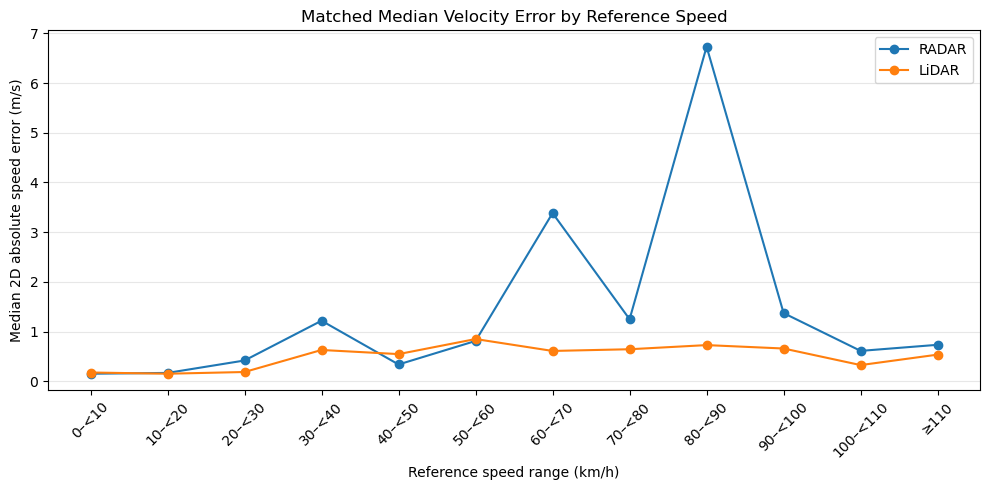

In [23]:
# Plot matched median absolute error by reference-speed range.

plot_data = speed_performance_summary.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_data["speed_range_kmh"],
    plot_data["RADAR_median_abs_error_mps"],
    marker="o",
    label="RADAR",
)

ax.plot(
    plot_data["speed_range_kmh"],
    plot_data["LiDAR_median_abs_error_mps"],
    marker="o",
    label="LiDAR",
)

ax.set_xlabel("Reference speed range (km/h)")
ax.set_ylabel("Median 2D absolute speed error (m/s)")

ax.set_title(
    "Matched Median Velocity Error by Reference Speed"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

The matched median error shows similar RADAR and LiDAR performance at low reference speeds. At several medium- and high-speed ranges, the RADAR median error becomes substantially larger and more variable, while the LiDAR median error remains comparatively stable.

However, the number of matched intervals varies considerably between speed ranges. These patterns therefore describe the observed TruckScenes results and should not be interpreted as evidence that reference speed alone causes the changes in estimation error.

## 5. Compare Sensor Information Efficiency

Sensor information efficiency is evaluated separately from velocity accuracy.

In this analysis, efficiency refers to the amount and type of usable target-related sensor information acquired under equivalent observation conditions. It does not represent computational efficiency, storage requirements, loading speed, or hardware processing cost.

Three aspects are considered:

- **Information availability:** whether target-associated sensor information is present at both endpoints of a reference interval.
- **Information amount:** the amount of target-associated information recorded within each sensor modality.
- **Information type:** the additional measurement properties provided by each sensing modality.

RADAR returns and LiDAR points are not treated as equivalent information units. Their absolute counts are therefore analysed separately rather than combined into a common efficiency score.

Native sensor observation frequency is also considered separately from the keyframe-level comparison because the target-level velocity analyses use comparable reference intervals rather than all intermediate sensor observations.

In [24]:
# Summarise target-related sensor information at the interval level.

information_summary = pd.DataFrame({
    "Information available intervals": [
        comparison_df["radar_info_available"].sum(),
        comparison_df["lidar_info_available"].sum(),
    ],
    "Information availability (%)": [
        comparison_df["radar_info_available"].mean() * 100,
        comparison_df["lidar_info_available"].mean() * 100,
    ],
    "Median information amount": [
        comparison_df.loc[
            comparison_df["radar_info_available"],
            "radar_return_count",
        ].median(),

        comparison_df.loc[
            comparison_df["lidar_info_available"],
            "lidar_point_count",
        ].median(),
    ],
    "Mean information amount": [
        comparison_df.loc[
            comparison_df["radar_info_available"],
            "radar_return_count",
        ].mean(),

        comparison_df.loc[
            comparison_df["lidar_info_available"],
            "lidar_point_count",
        ].mean(),
    ],
}, index=["RADAR returns", "LiDAR points"])

information_summary.round(2)

,Information available intervals,Information availability (%),Median information amount,Mean information amount
RADAR returns,7706,48.95,7.0,12.50
LiDAR points,15743,100.00,90.0,1611.99


In [25]:
# Inspect the distribution of target-associated information amounts.

radar_amount = comparison_df.loc[
    comparison_df["radar_info_available"],
    "radar_return_count",
]

lidar_amount = comparison_df.loc[
    comparison_df["lidar_info_available"],
    "lidar_point_count",
]


information_amount_distribution = pd.DataFrame({
    "Median": [
        radar_amount.median(),
        lidar_amount.median(),
    ],
    "25th percentile": [
        radar_amount.quantile(0.25),
        lidar_amount.quantile(0.25),
    ],
    "75th percentile": [
        radar_amount.quantile(0.75),
        lidar_amount.quantile(0.75),
    ],
    "90th percentile": [
        radar_amount.quantile(0.90),
        lidar_amount.quantile(0.90),
    ],
    "95th percentile": [
        radar_amount.quantile(0.95),
        lidar_amount.quantile(0.95),
    ],
    "Maximum": [
        radar_amount.max(),
        lidar_amount.max(),
    ],
}, index=["RADAR returns", "LiDAR points"])

information_amount_distribution.round(1)

,Median,25th percentile,75th percentile,90th percentile,95th percentile,Maximum
RADAR returns,7.0,4.0,15.0,29.0,44.0,149.0
LiDAR points,90.0,21.0,539.0,2963.0,6662.8,101849.0


In [26]:
# Summarise sensor information availability and amount across reference-speed ranges.

information_speed_summary = (
    comparison_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .agg(
        Reference_intervals=(
            "start_annotation_token",
            "size",
        ),

        RADAR_info_available=(
            "radar_info_available",
            "sum",
        ),

        LiDAR_info_available=(
            "lidar_info_available",
            "sum",
        ),
    )
)


information_speed_summary["RADAR_info_availability_pct"] = (
    information_speed_summary["RADAR_info_available"]
    / information_speed_summary["Reference_intervals"]
    * 100
)

information_speed_summary["LiDAR_info_availability_pct"] = (
    information_speed_summary["LiDAR_info_available"]
    / information_speed_summary["Reference_intervals"]
    * 100
)


radar_amount_by_speed = (
    comparison_df[
        comparison_df["radar_info_available"]
    ]
    .groupby(
        "speed_range_kmh",
        observed=False,
    )["radar_return_count"]
    .median()
)

lidar_amount_by_speed = (
    comparison_df[
        comparison_df["lidar_info_available"]
    ]
    .groupby(
        "speed_range_kmh",
        observed=False,
    )["lidar_point_count"]
    .median()
)


information_speed_summary[
    "RADAR_median_return_count"
] = radar_amount_by_speed

information_speed_summary[
    "LiDAR_median_point_count"
] = lidar_amount_by_speed


information_speed_summary.round(2)

,Reference_intervals,RADAR_info_available,LiDAR_info_available,RADAR_info_availability_pct,LiDAR_info_availability_pct,RADAR_median_return_count,LiDAR_median_point_count
speed_range_kmh,,,,,,,
0–<10,6870,3712,6870,54.03,100.0,7.0,131.0
10–<20,2028,1087,2028,53.60,100.0,8.0,124.0
20–<30,1211,572,1211,47.23,100.0,7.0,61.0
30–<40,799,350,799,43.80,100.0,6.0,57.0
40–<50,510,169,510,33.14,100.0,4.0,34.0
50–<60,424,166,424,39.15,100.0,9.0,37.5
60–<70,542,292,542,53.87,100.0,9.0,78.0
70–<80,823,358,823,43.50,100.0,7.0,61.0
80–<90,797,413,797,51.82,100.0,12.0,130.0


### 5.1 Target-Information Availability by Reference Speed

Target-information availability is compared across the common reference-speed ranges.

An interval is considered information-available when target-associated sensor information is present at both interval endpoints. This measure is distinct from velocity-estimation availability because the presence of sensor information does not necessarily guarantee that the current velocity-estimation method can produce a valid estimate.

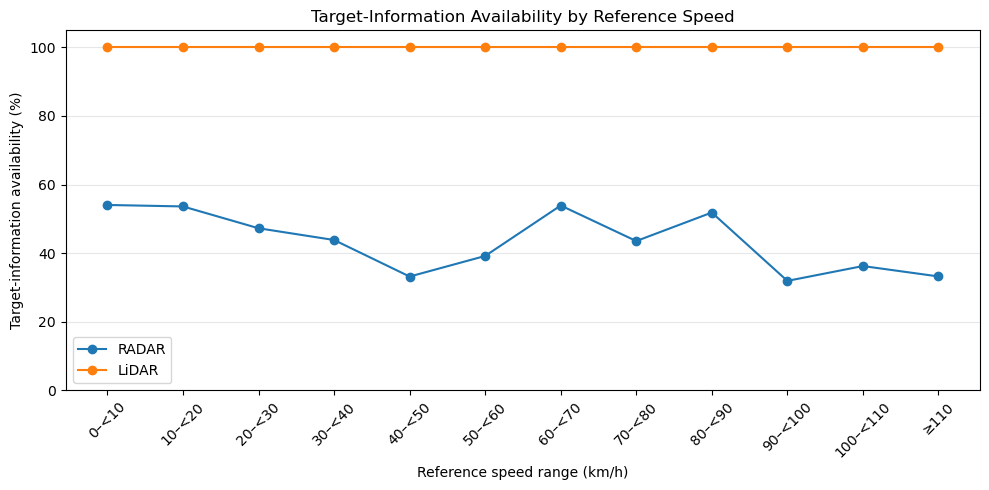

In [27]:
# Plot target-information availability by reference-speed range.

plot_data = information_speed_summary.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_data["speed_range_kmh"],
    plot_data["RADAR_info_availability_pct"],
    marker="o",
    label="RADAR",
)

ax.plot(
    plot_data["speed_range_kmh"],
    plot_data["LiDAR_info_availability_pct"],
    marker="o",
    label="LiDAR",
)

ax.set_xlabel("Reference speed range (km/h)")
ax.set_ylabel("Target-information availability (%)")

ax.set_title(
    "Target-Information Availability by Reference Speed"
)

ax.set_ylim(0, 105)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

LiDAR target information is available at both interval endpoints across all reference-speed ranges, while RADAR target-information availability varies between approximately 32% and 54%. This information availability should not be confused with velocity-estimation availability, since additional method-specific conditions are required to derive a usable velocity estimate.

### 5.2 Relative Information Amount by Reference Speed

RADAR return counts and LiDAR point counts represent different types of sensor information and are therefore not directly comparable as equivalent units.

To examine how target-associated information amount changes with reference speed, the median information amount in each speed range is normalised by the overall median within the same sensor modality.

A normalised value of 1 represents the overall modality median. Values above or below 1 indicate relatively higher or lower target-associated information within that modality. This normalisation is used only to compare trends and does not define a common RADAR–LiDAR efficiency unit.

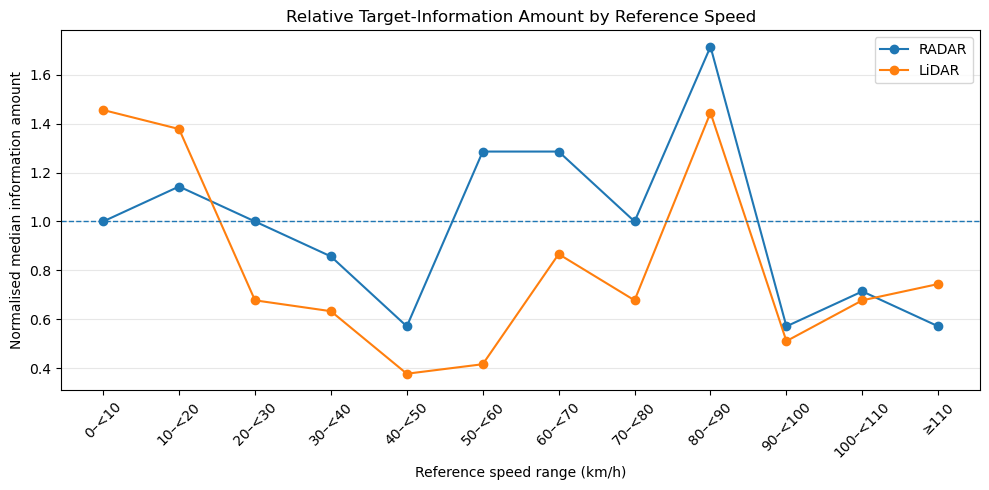

In [28]:
# Compare relative information-amount trends across speed ranges.

radar_overall_median = (
    comparison_df.loc[
        comparison_df["radar_info_available"],
        "radar_return_count",
    ].median()
)

lidar_overall_median = (
    comparison_df.loc[
        comparison_df["lidar_info_available"],
        "lidar_point_count",
    ].median()
)


plot_data = information_speed_summary.reset_index().copy()

plot_data["RADAR_normalised_information"] = (
    plot_data["RADAR_median_return_count"]
    / radar_overall_median
)

plot_data["LiDAR_normalised_information"] = (
    plot_data["LiDAR_median_point_count"]
    / lidar_overall_median
)


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_data["speed_range_kmh"],
    plot_data["RADAR_normalised_information"],
    marker="o",
    label="RADAR",
)

ax.plot(
    plot_data["speed_range_kmh"],
    plot_data["LiDAR_normalised_information"],
    marker="o",
    label="LiDAR",
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Reference speed range (km/h)")
ax.set_ylabel("Normalised median information amount")

ax.set_title(
    "Relative Target-Information Amount by Reference Speed"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

The normalised information amounts vary across reference-speed ranges for both sensor modalities, with no simple monotonic relationship between reference speed and target-associated information amount.

Because RADAR returns and LiDAR points are normalised independently by their own overall medians, this figure compares relative within-modality trends only. It does not imply that equal normalised values represent equal amounts of sensor information.

### 5.3 Overall Efficiency Comparison and Native Observation Frequency

The two sensing modalities provide different types of target-related information.

| Aspect | RADAR | LiDAR |
|---|---|---|
| Spatial information | 3D return position | Dense 3D point geometry |
| Direct velocity-related information | Relative velocity components are provided in the RADAR returns | No direct velocity field |
| Derived target velocity | Reconstructed from ego-compensated RADAR radial constraints | Derived from displacement between consecutive LiDAR target positions |
| Additional point-level information | RCS-related return information where available in the validated RADAR fields | Intensity and point-level timestamps |
| Target information amount used here | Target-associated RADAR return count | Dataset-provided target-associated LiDAR point count |

These information types are complementary rather than directly interchangeable. A LiDAR point and a RADAR return therefore cannot be treated as equivalent units in a common efficiency score.

The keyframe-level comparison in this notebook also does not represent the full native acquisition rate of the sensors. Previous sensor-observation analysis found that LiDAR operates at approximately 10 Hz, while RADAR operates at approximately 19.5 Hz. Native observation frequency is therefore considered as a separate sensor characteristic rather than being combined with keyframe-level information amount or velocity accuracy.

The higher native RADAR observation frequency indicates that RADAR can provide sensor observations more frequently in time, but this does not by itself imply greater velocity accuracy or greater target-information availability at the common keyframe intervals.

In [29]:
# Summarise the main evidence used for the sensor-information
# efficiency comparison.

total_intervals = len(comparison_df)

radar_info_available = (
    comparison_df["radar_info_available"].sum()
)

lidar_info_available = (
    comparison_df["lidar_info_available"].sum()
)

radar_velocity_available = (
    comparison_df["radar_velocity_available"].sum()
)

lidar_velocity_available = (
    comparison_df["lidar_velocity_available"].sum()
)


radar_info_availability_pct = (
    radar_info_available
    / total_intervals
    * 100
)

lidar_info_availability_pct = (
    lidar_info_available
    / total_intervals
    * 100
)

radar_velocity_availability_pct = (
    radar_velocity_available
    / total_intervals
    * 100
)

lidar_velocity_availability_pct = (
    lidar_velocity_available
    / total_intervals
    * 100
)


radar_velocity_yield_pct = (
    radar_velocity_available
    / radar_info_available
    * 100
)

lidar_velocity_yield_pct = (
    lidar_velocity_available
    / lidar_info_available
    * 100
)


radar_median_information = (
    comparison_df.loc[
        comparison_df["radar_info_available"],
        "radar_return_count",
    ].median()
)

lidar_median_information = (
    comparison_df.loc[
        comparison_df["lidar_info_available"],
        "lidar_point_count",
    ].median()
)


efficiency_evidence_summary = pd.DataFrame(
    {
        "RADAR": [
            f"{radar_info_available} "
            f"({radar_info_availability_pct:.2f}%)",

            f"{radar_velocity_available} "
            f"({radar_velocity_availability_pct:.2f}%)",

            f"{radar_velocity_yield_pct:.2f}%",

            f"{radar_median_information:.0f} returns",

            "≈19.5 Hz",
        ],

        "LiDAR": [
            f"{lidar_info_available} "
            f"({lidar_info_availability_pct:.2f}%)",

            f"{lidar_velocity_available} "
            f"({lidar_velocity_availability_pct:.2f}%)",

            f"{lidar_velocity_yield_pct:.2f}%",

            f"{lidar_median_information:.0f} points",

            "≈10 Hz",
        ],
    },
    index=[
        "Target-information availability",
        "Velocity-estimation availability",
        "Velocity yield given information",
        "Median target-information amount",
        "Approx. native observation frequency",
    ],
)

efficiency_evidence_summary

,RADAR,LiDAR
Target-information availability,7706 (48.95%),15743 (100.00%)
Velocity-estimation availability,3016 (19.16%),8007 (50.86%)
Velocity yield given information,39.14%,50.86%
Median target-information amount,7 returns,90 points
Approx. native observation frequency,≈19.5 Hz,≈10 Hz


## 6. Summary and Limitations

This notebook compared RADAR and LiDAR vehicle-motion performance under the same annotation-derived reference-speed conditions using a common interval-level comparison dataset.

A total of 15,743 valid vehicle reference intervals were retained. Stable RADAR-derived 2D velocity was available for 3,016 intervals (19.16%), while the current LiDAR-derived velocity method produced estimates for 8,007 intervals (50.86%). Both estimates were simultaneously available for 2,899 intervals.

Across all sensor-specific available estimates, the median 2D absolute speed error was 0.277 m/s for RADAR and 0.224 m/s for LiDAR. However, the RADAR error distribution contained a substantially heavier upper tail, producing a much larger mean error.

On the matched subset of 2,899 intervals, the median errors were very similar: 0.266 m/s for RADAR and 0.263 m/s for LiDAR. In contrast, the matched mean errors were 6.455 m/s and 0.613 m/s, respectively, while the 90th-percentile errors were 9.558 m/s and 1.437 m/s. The current LiDAR baseline therefore showed more consistent error behaviour on the matched intervals, while the typical median error of the two methods was similar.

Performance also varied across reference-speed ranges. RADAR and LiDAR showed similar median errors at low speeds, while RADAR produced larger and more variable median errors in several medium- and high-speed ranges. These patterns should be interpreted cautiously because the number of matched observations differs substantially between speed ranges.

The sensor-information comparison also showed important differences between the two modalities. Target-associated RADAR information was available at both interval endpoints for 7,706 intervals (48.95%), compared with all 15,743 intervals for the dataset-provided LiDAR target information. The corresponding velocity-estimation availability was lower for both methods, demonstrating that target-information availability does not directly imply velocity-estimation availability.

Among intervals with target information available, approximately 39.14% produced a stable RADAR velocity estimate and 50.86% produced a valid LiDAR-derived velocity estimate under the current methods. These percentages are method-dependent and should not be interpreted as intrinsic sensor efficiency scores.

RADAR and LiDAR also provide different types and amounts of information. The median interval-level target-associated information amount was 7 RADAR returns and 90 LiDAR points, but these values are not directly comparable because a RADAR return and a LiDAR point are not equivalent information units. The normalised information analysis was therefore used only to compare within-modality trends across reference-speed conditions.

Native observation frequency provides a separate efficiency characteristic. RADAR operates at approximately 19.5 Hz, compared with approximately 10 Hz for LiDAR in the current dataset. This higher RADAR acquisition frequency indicates more frequent native temporal observations, but it should not be combined directly with the keyframe-level availability, information amount, or velocity-accuracy metrics.

### Limitations

Several limitations should be considered when interpreting these results.

- The reported RADAR and LiDAR velocity availabilities depend on the specific estimation methods used in this project rather than representing intrinsic sensor availability. The RADAR baseline requires a stable 2D reconstruction from ego-compensated radial constraints, while the LiDAR baseline requires consecutive same-sensor observations with sufficient target-associated point support.
- The primary cross-sensor accuracy comparison is limited to 2D ground-plane speed. A directly comparable validated RADAR 3D target-velocity estimate was not established in the previous analysis.
- RADAR and LiDAR derive target velocity through different measurement processes. RADAR uses velocity-related measurements from sensor returns and reconstructs target motion from radial constraints, while LiDAR derives velocity from displacement between consecutive target-position estimates.
- The annotation-derived reference velocity is itself calculated from consecutive annotated target positions and is therefore a reference estimate rather than an independent direct velocity measurement.
- RADAR information amount is based on target-associated RADAR returns, while the LiDAR information amount uses the dataset-provided target-associated LiDAR point count. These quantities have different definitions and cannot be interpreted as equivalent information units.
- The main comparison is performed at common annotation/keyframe intervals. Native sensor acquisition frequencies are reported separately and are not fully exploited by the current target-level velocity-estimation baselines.
- The number of matched observations is uneven across reference-speed ranges, particularly in several higher-speed ranges. Apparent speed-dependent performance changes should therefore be treated as observed associations rather than causal effects.
- Large RADAR velocity errors were retained rather than removed as outliers. This preserves the behaviour of the validated baseline but results in a substantial difference between median and mean RADAR error.
- The results are specific to the current TruckScenes dataset configuration and the validated processing choices used in this project. Different datasets, association methods, velocity estimators, or filtering criteria may produce different performance and availability characteristics.

Overall, the comparison does not support reducing RADAR and LiDAR performance to a single statement that one sensor is universally better. Under the current TruckScenes analysis, LiDAR provides broader target-information and velocity-estimation coverage and more consistent matched velocity errors, while RADAR provides higher native observation frequency and direct velocity-related sensor information. These characteristics represent different trade-offs in vehicle-motion sensing rather than a single common efficiency metric.

In [30]:
# Save the validated comparison dataset.

comparison_df.to_pickle(
    RESULTS_ROOT / "comparison_df.pkl"
)

print("Saved comparison_df.pkl")
print("Rows:", len(comparison_df))

Saved comparison_df.pkl
Rows: 15743
